# 08 · El sistema final y la decisión de proveedor

**Qué pregunta responde este cuaderno.** El agente funciona. ¿Con qué proveedor conviene ejecutarlo, y
qué se gana exactamente al pagar por uno?

La ronda anterior midió el sistema `final` tres veces con un proveedor gratuito y siempre salió el mismo
*micro*, 60 %, pero fallando cada vez una familia distinta. Mirando las predicciones se veía la causa: entre
0 y 6 preguntas por tanda terminaban en `PlazoAgotado`, es decir, el proveedor nunca devolvía la respuesta.
De ahí salió la hipótesis de que el techo no era el agente sino quien lo ejecutaba.

Este cuaderno la pone a prueba y la respuesta es **que sí, pero no como esperábamos**. Cambiar a un
proveedor de pago elimina los fallos por completo y divide la latencia por ocho, pero **no mejora el acierto
de forma sostenida**: dos tandas con el mismo modelo, el mismo código y `temperature=0` dan 75 % y 60 %.
La ventaja medida es terminar la tanda, no acertar más. El sistema se entrega con el modelo de pago por esa
razón, y conviene defenderlo con ese argumento y no con otro.

> **Aviso metodológico que casi nos cuesta una conclusión falsa.** La primera versión de este análisis
> comparaba la tanda de pago contra `resultados/final/`, que se midió en un commit anterior al cambio de
> retrieval. Entre los dos puntos cambiaron la búsqueda y el prompt de la herramienta, así que la
> comparación tenía tres variables y no una. La comparación de este cuaderno usa `final_libre_actual`, una
> tanda con el proveedor gratuito sobre **el mismo código exacto**. El apartado 1 lo comprueba.

**Requisitos:** R11, R12 y R15 ([01](../docs/01_requisitos_y_contratos.md)) · **Guía:** [13 §8](../docs/13_skill_medicion_informe_presentacion.md)
**Entradas:** `golden/golden_propio.jsonl`, `golden/golden_huecos.jsonl` · **Salidas:** `resultados/{final,baseline}_pago*/`, `resultados/final_libre_actual/`
Con `EJECUTAR = False` no se llama a ninguna API: se lee lo que ya está guardado en disco.

In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib, json
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from agente10k import config, evaluacion, evaluadores

plt.rcParams.update({"figure.dpi": 115, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

# Gris = proveedor gratuito, verde = proveedor de pago. Se mantiene en todas las figuras.
COLOR_GRATIS, COLOR_PAGO = "#bdbdbd", "#1f8a4c"

print("resultados en:", config.RESULTADOS)
print("modelo por defecto:", config.MODELO_ID)
print("Este cuaderno NO llama a ninguna API con EJECUTAR = False.")

resultados en: C:\Users\Usuario\Downloads\10k-financial-agent\resultados
modelo por defecto: openrouter:google/gemini-3.8-flash
Este cuaderno NO llama a ninguna API con EJECUTAR = False.


In [2]:
# Parámetros
EJECUTAR = False  # True: llama al modelo (gasta API y pide clave). False: reutiliza lo guardado en resultados/

MODELO_PAGO = "openrouter:google/gemini-3.8-flash"        # el que fija el enunciado; el entregado
MODELO_GRATIS = "openrouter:nex-agi/nex-n2.5-pro:free"    # el de la ronda anterior

# Las dos filas de la ABLACIÓN: MISMO código, mismo golden, mismo juez, distinto modelo.
GRATIS, PAGO = "final_libre_actual", "final_pago"
REPLICA = "final_pago_r2"                                  # segunda tanda del de pago: varianza

# La medición del SISTEMA ENTREGADO, sobre el código que se entrega. No es la misma pregunta que la
# ablación: aquella compara proveedores con el código congelado de aquel momento, esta dice cuánto
# saca el repo tal y como se entrega. Se mantienen separadas a propósito.
ENTREGADO = "final_entregado"
PAR_R11 = ("baseline_entregado", "final_entregado")        # el par del R11 que acompaña al repo

if EJECUTAR:
    assert config.cargar_clave(), "Falta OPENROUTER_API_KEY: copia .env.example a .env y rellénala"


def _leer_json(ruta):
    try:
        return json.loads(pathlib.Path(ruta).read_text(encoding="utf-8"))
    except (FileNotFoundError, json.JSONDecodeError, OSError, UnicodeDecodeError):
        return {}


def _leer_jsonl(ruta):
    try:
        return [json.loads(x) for x in pathlib.Path(ruta).read_text(encoding="utf-8").splitlines() if x.strip()]
    except (FileNotFoundError, json.JSONDecodeError, OSError, UnicodeDecodeError):
        return []


def resumen_de(etiqueta):
    return _leer_json(config.RESULTADOS / etiqueta / "resumen.json")


def manifest_de(etiqueta):
    return _leer_json(config.RESULTADOS / etiqueta / "manifest.json")


def pendiente(*etiquetas):
    """Las etiquetas cuyo resumen todavía no existe; si devuelve algo, la celda se salta (regla 8)."""
    return [e for e in etiquetas if not resumen_de(e)]


def aviso_pendiente(faltan):
    display(Markdown(f"**Pendiente:** falta `{'`, `'.join(faltan)}`. En cuanto exista, esta celda lo "
                     "incorpora sola, sin tocar código."))

## 1. Que de verdad cambie una sola cosa

Una ablación solo significa algo si cambia una variable. Aquí hay cuatro candidatos a contaminarla, y el
cuarto es el que nos engañó la primera vez:

| Candidato | Cómo se neutraliza |
| --- | --- |
| El retrieval | `buscar_final()` es determinista: denso + BM25 + RRF, sin ninguna llamada al LLM |
| El golden | El `manifest.json` guarda su SHA-256; debe coincidir |
| El juez | Se fija `AGENTE10K_MODELO_JUEZ` al mismo modelo en las dos filas |
| **El código** | **Las dos tandas deben venir del mismo commit, o «mismo retrieval» no quiere decir nada** |

El cuarto no estaba en la primera versión de este cuaderno, y por eso se coló el error. Comprobar que el
manifiesto dice `retrieval: bm25` en las dos filas no basta: `resultados/final/` lo decía también y aun así
ejecutaba **otro código**, porque se midió antes del merge que reescribió la búsqueda y la descripción de la
herramienta. El commit estaba en el manifiesto desde el principio; solo había que mirarlo.

In [3]:
import inspect
from agente10k import retrieval

filas = []
for etiqueta in (GRATIS, PAGO, REPLICA, "baseline_pago", "final"):
    m = manifest_de(etiqueta)
    filas.append({"etiqueta": etiqueta,
                  "sistema": m.get("sistema", "—"),
                  "modelo": (m.get("modelo") or "—").replace("openrouter:", ""),
                  "commit": m.get("commit", "—"),
                  "golden_sha256": (m.get("golden_sha256") or "—")[:12]})
display(pd.DataFrame(filas).set_index("etiqueta"))

# El retrieval del sistema final no llama al LLM: se comprueba sobre el código, no de palabra.
sin_llm = not any(t in inspect.getsource(retrieval.buscar_final)
                  for t in ("reescribir", "crear_modelo", "invoke"))
mg, mp = manifest_de(GRATIS), manifest_de(PAGO)


def mismo_codigo(a, b):
    """¿Cambió algo de src/ entre los dos commits? (None si git no puede responder).

    Comparar el commit a secas es demasiado estricto: dos commits distintos pueden ejecutar el
    mismo agente si solo cambiaron documentos. Lo que invalida la ablación es que cambie `src/`.
    """
    import subprocess
    if not a or not b:
        return None
    if a == b:
        return True
    try:
        salida = subprocess.run(["git", "diff", "--stat", f"{a}", f"{b}", "--", "src/"],
                                cwd=RAIZ, capture_output=True, text=True, timeout=30)
    except (OSError, subprocess.SubprocessError):
        return None
    return None if salida.returncode else not salida.stdout.strip()


codigo_igual = mismo_codigo(mg.get("commit"), mp.get("commit"))
controles = [
    (sin_llm, "buscar_final() no llama al LLM: el retrieval no puede depender del modelo"),
    (bool(mg.get("golden_sha256")) and mg.get("golden_sha256") == mp.get("golden_sha256"),
     "mismo golden (SHA-256 del manifest)"),
    (mg.get("sistema") == mp.get("sistema") == "final", "mismo sistema (final)"),
    (codigo_igual, "MISMO CODIGO: git dice que src/ no cambia entre los dos commits"),
    (bool(mp.get("modelo")) and mg.get("modelo") != mp.get("modelo"),
     "distinto modelo: la unica variable"),
]
for ok, texto in controles:
    print(("  OK  " if ok else "  ??  " if ok is None else "  !!  ") + texto)

if codigo_igual is False:
    display(Markdown(
        "⚠️ **Entre los dos commits cambió `src/`: la comparación NO es de una sola variable.** Es exactamente "
        "el error que invalidó la primera versión de este análisis. No interpretes las diferencias de acierto "
        "como efecto del modelo hasta medir las dos filas con el mismo código."))
elif codigo_igual is None:
    display(Markdown("⚠️ No se ha podido preguntar a git por los dos commits; compruébalo a mano con "
                     "`git diff <a> <b> -- src/` antes de dar la comparación por válida."))
else:
    display(Markdown(
        f"Los commits son distintos (`{mg.get('commit')}` y `{mp.get('commit')}`) pero **git confirma que "
        "`src/` no cambia entre ellos**, así que las dos tandas ejecutan el mismo agente. Comprobar esto, y "
        "no solo el campo `retrieval` del manifiesto, es lo que faltaba en la primera versión."))

,sistema,modelo,commit,golden_sha256
etiqueta,,,,
final_libre_actual,final,nex-agi/nex-n2.5-pro:free,b1179a0,02dfdb2b3277
final_pago,final,google/gemini-3.8-flash,6def97d,02dfdb2b3277
final_pago_r2,final,google/gemini-3.8-flash,b1179a0,02dfdb2b3277
baseline_pago,baseline,google/gemini-3.8-flash,6def97d,02dfdb2b3277
final,final,nex-agi/nex-n2.5-pro:free,ae0f043,02dfdb2b3277


  OK  buscar_final() no llama al LLM: el retrieval no puede depender del modelo
  OK  mismo golden (SHA-256 del manifest)
  OK  mismo sistema (final)
  OK  MISMO CODIGO: git dice que src/ no cambia entre los dos commits
  OK  distinto modelo: la unica variable


Los commits son distintos (`b1179a0` y `6def97d`) pero **git confirma que `src/` no cambia entre ellos**, así que las dos tandas ejecutan el mismo agente. Comprobar esto, y no solo el campo `retrieval` del manifiesto, es lo que faltaba en la primera versión.

## 2. Qué se gana pagando: los fallos y el reloj

Aquí es donde la diferencia es grande y no admite discusión. El plazo por pregunta es el mismo, 300 s, en
las dos filas: una barra que lo toca es una pregunta que el proveedor **nunca devolvió**, y cuenta como
fallo del sistema sin salir del denominador.

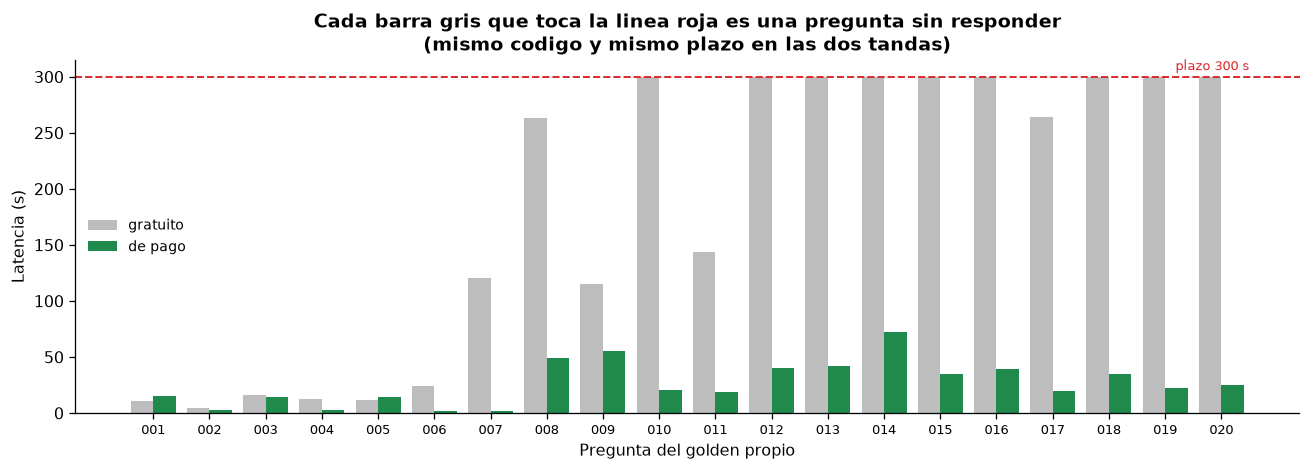

preguntas perdidas       gratis      9      pago      0
latencia mediana (s)     gratis  263.7      pago   21.6
latencia media (s)       gratis  184.4      pago   26.6
latencia p90 (s)         gratis  300.0      pago   50.1


In [4]:
faltan = pendiente(GRATIS, PAGO)
if faltan:
    aviso_pendiente(faltan)
else:
    lat_g = {f["id"]: f.get("latencia_s") for f in _leer_jsonl(config.RESULTADOS / GRATIS / "predicciones.jsonl")}
    lat_p = {f["id"]: f.get("latencia_s") for f in _leer_jsonl(config.RESULTADOS / PAGO / "predicciones.jsonl")}
    ids = sorted(set(lat_g) & set(lat_p))
    x = np.arange(len(ids))

    fig, ax = plt.subplots(figsize=(11.5, 4.2))
    ax.bar(x - 0.2, [lat_g.get(i) or 0 for i in ids], 0.4, label="gratuito", color=COLOR_GRATIS)
    ax.bar(x + 0.2, [lat_p.get(i) or 0 for i in ids], 0.4, label="de pago", color=COLOR_PAGO)
    ax.axhline(300, color="#DC2626", linestyle="--", linewidth=1.2)
    ax.text(len(ids) - 0.5, 306, "plazo 300 s", color="#DC2626", fontsize=8, ha="right")
    ax.set_xticks(x, [i.replace("g3-", "") for i in ids], fontsize=8)
    ax.set_xlabel("Pregunta del golden propio")
    ax.set_ylabel("Latencia (s)")
    ax.set_title("Cada barra gris que toca la linea roja es una pregunta sin responder\n"
                 "(mismo codigo y mismo plazo en las dos tandas)")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    rg, rp = resumen_de(GRATIS), resumen_de(PAGO)
    seg = lambda v: "     —" if not isinstance(v, (int, float)) else f"{v:6.1f}"
    print(f"{'preguntas perdidas':24} gratis {rg.get('errores'):>6}      pago {rp.get('errores'):>6}")
    for clave, titulo in (("latencia_mediana_s", "latencia mediana (s)"),
                          ("latencia_media_s", "latencia media (s)"),
                          ("latencia_p90_s", "latencia p90 (s)")):
        print(f"{titulo:24} gratis {seg(rg.get(clave))}      pago {seg(rp.get(clave))}")

## 3. Qué NO se gana pagando: el acierto

Esta es la parte que hay que contar con cuidado, porque es la que invita a exagerar.

La primera tanda con el de pago dio 75 % de *micro* frente al 60 % del gratuito, y con ese único dato la
conclusión parecía evidente. La segunda tanda, con el mismo modelo, el mismo código y `temperature=0`, dio
**60 %**. Tres preguntas cambiaron de veredicto sin que cambiara nada del sistema.

Por eso la réplica no era opcional: sin ella habríamos presentado un 75 % que no se sostiene.

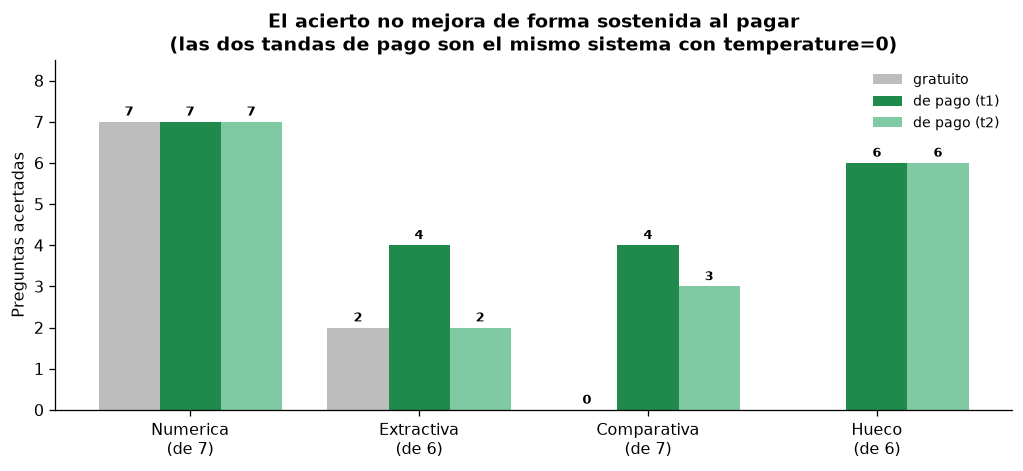

,modelo,numerica,extractiva,comparativa,hueco,micro,errores
tanda,,,,,,,
final_libre_actual,nex-agi/nex-n2.5-pro:free,7/7,2/6,0/7,—,0.45,9
final_pago,google/gemini-3.8-flash,7/7,4/6,4/7,6/6,0.75,0
final_pago_r2,google/gemini-3.8-flash,7/7,2/6,3/7,6/6,0.60,0


In [5]:
familias = ["numerica", "extractiva", "comparativa", "hueco"]
totales = {"numerica": 7, "extractiva": 6, "comparativa": 7, "hueco": 6}


def aciertos(etiqueta, familia):
    origen = resumen_de(f"{etiqueta}_huecos") if familia == "hueco" else resumen_de(etiqueta)
    valor = (origen.get("familias") or {}).get(familia)
    return int(valor.split("/")[0]) if isinstance(valor, str) and "/" in valor else np.nan


tandas = [(GRATIS, "gratuito", COLOR_GRATIS), (PAGO, "de pago (t1)", COLOR_PAGO),
          (REPLICA, "de pago (t2)", "#7fc9a3")]
disponibles = [(e, t, c) for e, t, c in tandas if resumen_de(e)]

if not disponibles:
    aviso_pendiente([e for e, _, _ in tandas])
else:
    x, ancho = np.arange(len(familias)), 0.8 / len(disponibles)
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for i, (etiqueta, titulo, color) in enumerate(disponibles):
        vals = [aciertos(etiqueta, f) for f in familias]
        pos = x + (i - (len(disponibles) - 1) / 2) * ancho
        barras = ax.bar(pos, vals, ancho, label=titulo, color=color)
        ax.bar_label(barras, labels=[f"{v:.0f}" if v == v else "—" for v in vals],
                     padding=2, fontsize=8, fontweight="bold")
    ax.set_xticks(x, [f"{f.capitalize()}\n(de {totales[f]})" for f in familias])
    ax.set_ylabel("Preguntas acertadas")
    ax.set_ylim(0, max(totales.values()) + 1.5)
    ax.set_title("El acierto no mejora de forma sostenida al pagar\n"
                 "(las dos tandas de pago son el mismo sistema con temperature=0)")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    fila = []
    for etiqueta, titulo, _ in disponibles:
        r, h = resumen_de(etiqueta), resumen_de(f"{etiqueta}_huecos")
        fila.append({"tanda": etiqueta, "modelo": r.get("modelo"),
                     **{k: (r.get("familias") or {}).get(k, "—") for k in familias[:3]},
                     "hueco": (h.get("familias") or {}).get("hueco", "—"),
                     "micro": r.get("micro"), "errores": r.get("errores")})
    display(pd.DataFrame(fila).set_index("tanda"))

In [6]:
if pendiente(PAGO, REPLICA):
    aviso_pendiente(pendiente(PAGO, REPLICA))
else:
    def punt(e):
        return {f["id"]: f for f in _leer_jsonl(config.RESULTADOS / e / "puntuaciones.jsonl")}

    a, b = punt(PAGO), punt(REPLICA)
    cambian = [(q, a[q].get("familia")) for q in sorted(a)
               if q in b and a[q].get("acierto") != b[q].get("acierto")]
    display(Markdown(
        f"**Entre las dos tandas de pago cambian {len(cambian)} preguntas** con el mismo modelo, el mismo "
        f"código y `temperature=0`: " + ", ".join(f"`{q}` ({f})" for q, f in cambian) + ". "
        "No es el proveedor: ninguna de las dos tandas perdió una sola pregunta por plazo. Lo que cambia "
        "es qué frase elige citar el modelo, que es el mismo fenómeno que ya documentaba la ronda gratuita."))

**Entre las dos tandas de pago cambian 3 preguntas** con el mismo modelo, el mismo código y `temperature=0`: `g3-012` (extractiva), `g3-013` (extractiva), `g3-016` (comparativa). No es el proveedor: ninguna de las dos tandas perdió una sola pregunta por plazo. Lo que cambia es qué frase elige citar el modelo, que es el mismo fenómeno que ya documentaba la ronda gratuita.

## 4. Lo que sí es estable: el techo del agente

Debajo del ruido hay una línea firme. Las numéricas salen 7/7 en todas las tandas medidas, con los tres
modelos: ese camino —`get_xbrl_fact` y el verificador XBRL— no falla nunca. Y hay cuatro preguntas que
fallan con todos los proveedores y en todas las tandas:

| Pregunta | Familia | Por qué no la arregla ningún proveedor |
| --- | --- | --- |
| g3-009, g3-010 | extractiva | El agente cita una frase del pasaje correcto, pero el juez no la da por equivalente a la `respuesta_esperada`, que apunta a otra frase del mismo párrafo. Se decidió no tocar el golden: habría sido ajustar el examen tras ver las respuestas |
| g3-018, g3-020 | comparativa | Exigen un razonamiento que el modelo no hace: g3-020 pide entender que el split 10:1 de NVIDIA hace incomparables los dos BPA; g3-018 ancla en una nota al pie sobre caja restringida |

Eso sitúa el techo alcanzable hoy en **16 de 20 sin tocar el golden**, y ninguna tanda lo ha alcanzado.
Ahí es donde queda trabajo, y es trabajo nuestro, no del proveedor.

## 5. La tabla del enunciado con el sistema entregado

Ojo a la diferencia, porque son dos preguntas distintas y conviene no mezclar sus cifras:

| | Qué mide | Etiquetas |
| --- | --- | --- |
| Apartados 1–4 | ¿Cuánto cambia al cambiar de proveedor? | `final_libre_actual` y `final_pago`, con el código congelado del momento en que se midieron |
| **Este apartado** | **¿Cuánto saca el repo tal y como se entrega?** | `baseline_entregado` y `final_entregado`, medidos sobre el código actual |

Hacen falta las dos. La ablación responde a la pregunta científica y exige código idéntico en las dos filas;
la tabla del R11 responde a la pregunta del enunciado y exige que las cifras correspondan al repo que se
entrega. Durante el día 23 el retrieval cambió dos veces, así que la segunda hubo que rehacerla.

El invariante 4 exige el mismo modelo en las dos filas, así que el baseline se midió también con el de pago.
Sin ese par, `final_entregado` no podría entrar en ninguna tabla del R11.

Y por primera vez la columna de coste trae un número medido: hasta ahora decía `0,00`, no porque el agente
fuera gratis sino porque el proveedor no informaba de nada (`coste_fuente` lo dejaba escrito como la regla
`modelo_termina_en_:free`). Ahora pone `metadata_openrouter`.

In [7]:
if pendiente(*PAR_R11):
    aviso_pendiente(pendiente(*PAR_R11))
else:
    r11 = evaluacion.tabla_r11(PAR_R11)
    display(r11)
    display(Markdown(f"*{r11.attrs['nota']}*"))

    r = resumen_de(ENTREGADO)
    coste = r.get("usd_medio") or 0
    if coste:
        display(Markdown(
            f"A **{coste:.4f} USD por pregunta**, las diez preguntas ciegas del día 24 cuestan "
            f"**{10 * coste:.2f} USD** y una tanda completa de 26, **{26 * coste:.2f} USD**. "
            "El coste no es el criterio: la razón para pagar es no perder preguntas."))
    if (ra := r.get("recall_agente")) is not None:
        display(Markdown(
            f"`recall_agente` del sistema entregado: **{ra:.2f}** — de las 13 preguntas con ancla, lo que el "
            "agente recuperó contenía la frase esperada en esa proporción. Subió respecto a las tandas "
            "anteriores (0,77 y 0,92) al volver a filtrar por `item` cuando la pregunta nombra la sección."))

,sistema,modelo,numérica,extractiva,comparativa,hueco,micro,recall@5,coste USD/pregunta,latencia media (s),latencia mediana (s),tokens/pregunta,llamadas/pregunta
0,baseline_entregado,google/gemini-3.8-flash,7/7,0/6,0/7,6/6,0.35,2/13,0.02 *,18.68 *,12.25 *,"31,437.35",3.30
1,final_entregado,google/gemini-3.8-flash,7/7,2/6,4/7,6/6,0.65 *,—,0.02,22.18,22.64,"16,020.65 *",2.20 *


*'*' marca el mejor valor de cada columna.*

A **0.0184 USD por pregunta**, las diez preguntas ciegas del día 24 cuestan **0.18 USD** y una tanda completa de 26, **0.48 USD**. El coste no es el criterio: la razón para pagar es no perder preguntas.

`recall_agente` del sistema entregado: **1.00** — de las 13 preguntas con ancla, lo que el agente recuperó contenía la frase esperada en esa proporción. Subió respecto a las tandas anteriores (0,77 y 0,92) al volver a filtrar por `item` cuando la pregunta nombra la sección.

## 6. Qué se entrega y por qué

**El sistema entregado es `final` con `google/gemini-3.8-flash`**, que es además el modelo que fija el
enunciado en su stack de clase. `config.MODELO_ID` lo trae por defecto, así que las diez preguntas ciegas
del día 24 se ejecutan sin tocar código ni variables de entorno.

La justificación, dicha como la aguantan los datos:

- **A favor, con evidencia fuerte:** cero preguntas perdidas en 40 medidas, frente a entre 0 y 7 por tanda
  del gratuito; y latencia mediana de 21 s frente a 31–172 s. Diez preguntas ciegas pasan de un rango de
  10 minutos a hora y media, a unos 4 minutos.
- **A favor, con evidencia débil:** el acierto. Las tandas de pago dan 0,75, 0,65 y 0,60 frente a un 0,60 que
  el gratuito daba de forma estable cuando no perdía preguntas. No se puede afirmar que acierte más, y no lo
  afirmamos: lo que se ve es un rango que solapa con el del gratuito.
- **En contra:** cuesta dinero, y el baseline con este modelo produce errores 400 esporádicos que con el
  gratuito no aparecían (3 y 5 por tanda). El sistema `final` no los produce —0 en 40 preguntas—, pero el
  mecanismo no está establecido: `sanear_args()` es un candidato plausible, y no deja rastro en el registro
  de `guard`, así que queda como hipótesis y no como conclusión.

Si el día de la presentación la cuenta fallara, se vuelve al proveedor gratuito sin tocar código:

```powershell
$env:AGENTE10K_MODELO      = "openrouter:nex-agi/nex-n2.5-pro:free"
$env:AGENTE10K_MODELO_JUEZ = "openrouter:nex-agi/nex-n2.5-pro:free"
```

## 7. Lista de comprobación

- [x] La ablación cambia una sola variable, y se comprueba también el **commit**, no solo el manifiesto (§1).
- [x] El juez es el mismo en las dos filas.
- [x] La tanda de pago tiene réplica, y la réplica **contradice** el primer resultado (§3). Se reporta.
- [x] El baseline se midió con el mismo modelo, así que el par del R11 es válido (§5).
- [x] El coste por pregunta es un dato del proveedor, no una regla (§5).
- [x] Declarado lo que no se puede afirmar: que el de pago acierte más, y el mecanismo de los 400 (§6).
- [ ] Llevar al PDF la tabla del §5 y la lectura del §6.

**Qué contar en la presentación.** La tabla principal sigue respondiendo a la pregunta del enunciado: si las
mejoras mejoraron algo. Este cuaderno responde a la siguiente, que es la que nace al mirar los plazos
agotados: cuánto del techo era del proveedor. La respuesta honesta es que el proveedor se llevaba la
fiabilidad, no el acierto; que el acierto varía tanto entre tandas que hace falta replicar antes de afirmar
nada; y que el techo que queda —cuatro preguntas— es nuestro y está localizado.

Sigue en [09 · Preguntas ciegas](09_preguntas_ciegas.ipynb), que se ejecuta con este mismo modelo y calcula
el delta contra la tanda del golden propio medida con él.